# Test long-short term memory (LSTM) model on Mackey-Glass Time series (MG) data

This notebook show the experiments testing performance of LSTM on long-term prediction of chaotic data (MG data).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from sklearn.preprocessing import MinMaxScaler

## Data Generation

In [2]:
import numpy as np
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=1,N=2000000,delta=0.01):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  T,X = T[::100],X[::100]
  return T,X

In [3]:
def create_sequences(data, input_len=512, output_len=64):
    X, y = [], []
    for i in range(len(data) - input_len - output_len + 1):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y)

In [ ]:
_,X_60 = MG_generate_interp(tau=60,N=2000000)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(X_60.reshape(-1,1))
X, y = create_sequences(scaled_data, 512, 64)

In [5]:
_,X_200 = MG_generate_interp(tau=200,N=2000000)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(X_200.reshape(-1,1))
X, y = create_sequences(scaled_data, 512, 64)

In [6]:
X_train, X_val, X_test = X[:10000], X[10000:12000], X[12000:]
y_train, y_val, y_test = y[:10000], y[10000:12000], y[12000:]

In [7]:
input_len = 512
output_len = 64

## Model construction

In [8]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(input_len, 1)),
    LSTM(128),
    Dense(output_len)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 512, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,400 (806.25 KB)

 Trainable params: 206,400 (806.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train[5000:9000], y_train[5000:9000],
    validation_data=(X_val[:200], y_val[:200]),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - loss: 0.0429 - val_loss: 0.0331
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 0.0401 - val_loss: 0.0363
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0391 - val_loss: 0.0350
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 0.0388 - val_loss: 0.0346
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0385 - val_loss: 0.0335
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - loss: 0.0372 - val_loss: 0.0335


## Rolling prediction

In [10]:
def predict_autoregressive(model, init_seq, predict_steps=1024, step_size=64):
    init_seq = init_seq[-input_len:].reshape(1, input_len, 1)
    output = []

    for _ in range(predict_steps // step_size):
        pred = model.predict(init_seq, verbose=0)
        output.extend(pred[0])

        # roll window
        init_seq = np.concatenate([init_seq[0, step_size:], pred.reshape(step_size, 1)])
        init_seq = init_seq.reshape(1, input_len, 1)

    return np.array(output)

In [12]:
forecasts = []
true_values = []
for i in range(100):
  if i%10==0:
    print(i)
  init_seq = X_test[10*i]
  forecast_scaled = predict_autoregressive(model, init_seq, predict_steps=1024)
  forecast = scaler.inverse_transform(forecast_scaled.reshape(-1, 1))
  forecasts.append(forecast)
  true_values.append(X_200[12512+10*i:13536+10*i])

0
10
20
30
40
50
60
70
80
90


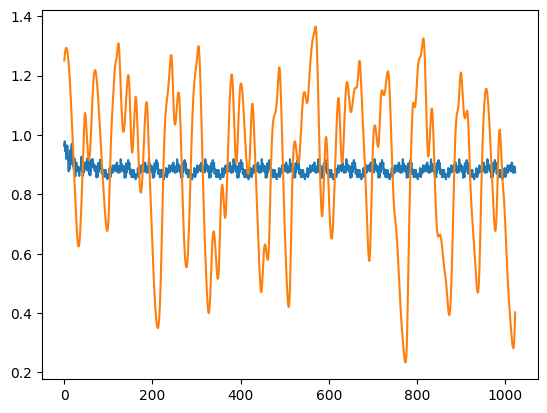

In [13]:
plt.plot(forecasts[0])
plt.plot(true_values[0])
plt.show()

## save results

In [ ]:
import pickle

with open('LSTM_chaos_test.pkl', 'wb') as f:
    pickle.dump((forecasts,true_values),f)